# Project Overview: Delivery Time Prediction

## **Problem Statement**

This project builds a regression model to predict food delivery time (in minutes) from restaurant to customer. The model considers multiple factors including:
- Rider attributes (rating, city, vehicle type)
- Environmental conditions (weather, traffic, holidays)
- Location data (restaurant and delivery coordinates)

**Why Accurate Predictions Matter**

Delivery time estimates impact three key stakeholders in the food delivery ecosystem:

| Stakeholder | Benefit |
|-------------|---------|
| **Customers** | Better experience through reliable ETAs, increasing satisfaction and retention |
| **Riders** | Fair workload distribution and improved earnings through optimized routing |
| **Restaurants** | Efficient order preparation planning and fewer complaints |

**Business Impact**

The food delivery market is highly competitive. Global players like Uber Eats struggled in India due to lack of local market understanding, while regional players (Swiggy, Zomato) succeeded. Beyond food, this model applies to vegetable, fruit, medicine, and parcel delivery services.

**Key Benefits:**

- **Customer retention**: Reliable ETAs build trust and repeat usage
- **Rider retention**: Fair performance metrics and workload balance
- **Proactive resource allocation**: Identifying high-delay scenarios enables:
  - Deploying additional riders
  - Prioritizing specific orders
  - Better peak-time planning

In a market where delivery experience determines success, accurate time prediction is a strategic advantage.

## **How ML Helps?**

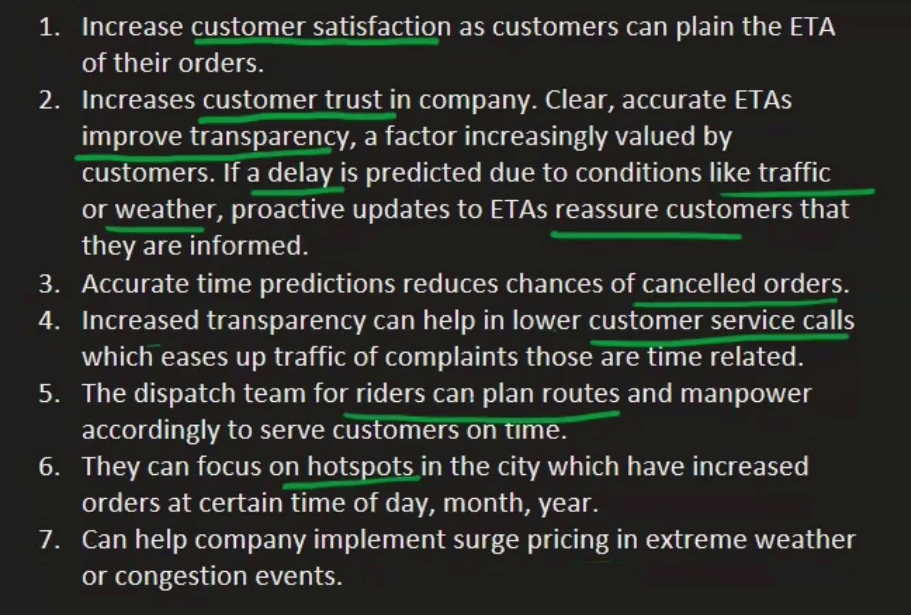

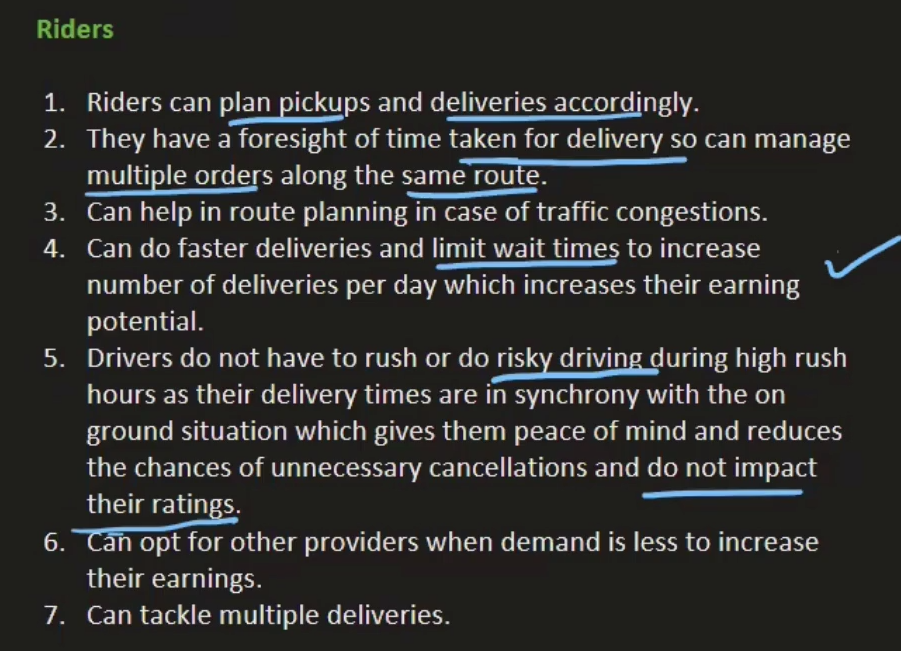

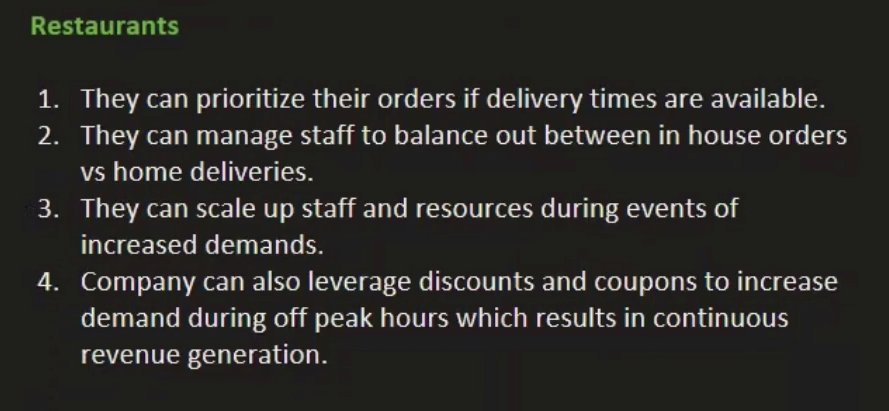

## Which metrics to use?

- RMSE & MAE
- Since we're predicting delivery time (in **minutes**), both RMSE and MAE output in the same unit—making results directly interpretable for **customers, riders, and restaurants**.

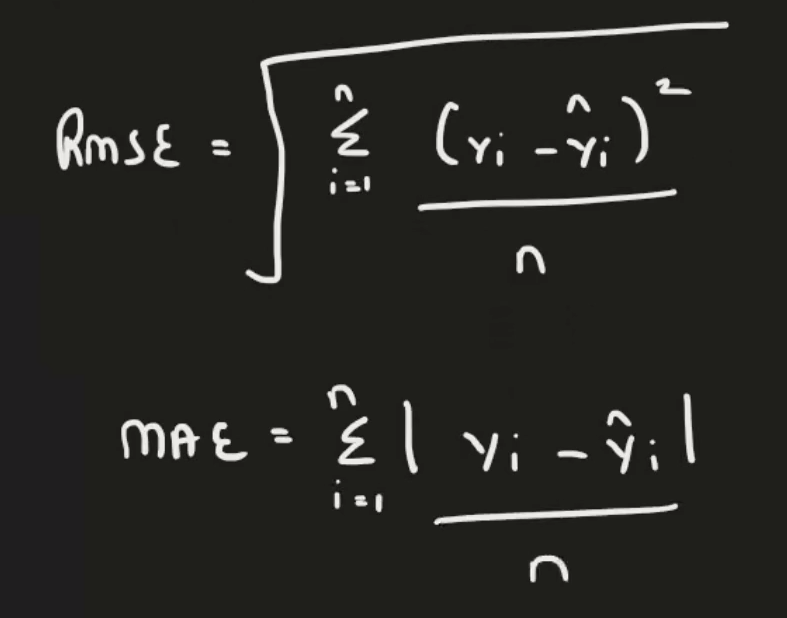

- **MAE (Mean Absolute Error)** is our **primary metric** because:
    - Treats all errors equally
    - Extreme weather/traffic produce **valid high-delivery times**, not outliers
    - RMSE squares these errors, disproportionately penalizing the model for correctly predicting legitimate delay scenarios
    - MAE provides a fairer, more realistic performance assessment across all conditions

- **RMSE** serves as a secondary metric for sensitivity analysis.
- Both metrics ensure stakeholders communicate in the same **time-based language**—minutes.

## Improvement in buisness

- Accurate delivery time prediction drives measurable improvements across key performance indicators:

| Metric | Impact |
|--------|--------|
| **Customer Satisfaction** | Reliable ETAs reduce complaints and cancellations |
| **Customer Retention** | Satisfied customers churn less, improving LTV |
| **Average Order Value (AOV)** | Happy customers order more frequently and spend more |
| **Delivery Success Rate** | Fewer late deliveries and order cancellations |
| **Operational Efficiency** | Better routing and clustering optimize driver workload |
| **Customer Support Cost** | Fewer ETA-related calls reduce operational expenses |
| **Order Cancellation Rate** | Accurate ETAs set correct expectations, minimizing last-minute cancellations |

## Flow of the project

- Create project folder
- Setup git, github, dvc, mlflow dagshub, s3 remote
- Perform Experimentation → Find best model & parameters
- create DVC pipeline and log model to model registry
- Perform evaluation tests → If success: Push model to production → Create FastAPI using latest model on production → API tests → If success: Dockerize api → Push docker image to ECR → Deploy docker image to EC2 CodeDeploy / ECS / EKS

# Data Assesment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [3]:
df = pd.read_csv(r'D:\ML Project\campusx_mlops\swiggy-delivery-time-prediction-v1\data\swiggy.csv')

## look at the data using df.head(), sample(), tail() etc

In [4]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [5]:
# ID: order id
# Delivery_person_ID: rider id (we can extract city details from this col)
# Delivery_person_Age: rider age
# Delivery_person_Ratings: rider ratings
# Restaurant_latitude: origin lat
# Restaurant_longitude: origin long
# Delivery_location_latitude: destination lat
# Delivery_location_longitude: destination long
# Order_Date: Order_Date
# Time_Orderd: Time_Orderd
# Time_Order_picked: Time_Order_picked
# Weatherconditions: Weatherconditions --> remove "conditions"
# Road_traffic_density: Road_traffic_density
# Vehicle_condition: Vehicle_condition
# Type_of_order: Type_of_order
# Type_of_vehicle: Type_of_vehicle
# multiple_deliveries: multiple_deliveries (0,1)
# Festival: yes or no
# City: city type
# Time_taken(min: time taken in delivery 

In [6]:
#shape of data
rows, cols = df.shape
print(f"data has {rows} rows and {cols} cols")

data has 45593 rows and 20 cols


In [7]:
#datatype of cols
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

In [8]:
#age and ratings should be float
#order date & time should datetime
#multiple_deliveries should be int
#vehicale condition to categorical
#time taken (target) should be in numbers

In [9]:
#missing values
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [10]:
#missing values in whole data
df.isnull().sum().sum()

np.int64(0)

In [11]:
#50 rows sample
df.sample(50)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
18461,0x42a1,JAPRES11DEL03,30,4.6,26.902940,75.793007,26.962940,75.853007,01-04-2022,21:20:00,21:35:00,conditions Cloudy,Jam,0,Drinks,motorcycle,0,No,Metropolitian,(min) 26
3877,0xa448,BANGRES14DEL01,29,4.7,12.949934,77.699386,13.019934,77.769386,27-03-2022,19:35:00,19:45:00,conditions Sandstorms,Jam,0,Drinks,motorcycle,0,No,Metropolitian,(min) 28
44375,0x6a28,RANCHIRES010DEL02,26,4.9,23.354422,85.332900,23.484422,85.462900,02-04-2022,21:10:00,21:15:00,conditions Sandstorms,Jam,2,Snack,electric_scooter,1,No,Metropolitian,(min) 19
8179,0x4548,VADRES15DEL02,31,4.7,0.000000,0.000000,0.020000,0.020000,03-04-2022,09:10:00,09:20:00,conditions Fog,Low,1,Drinks,motorcycle,1,No,Metropolitian,(min) 15
38696,0x6d3a,SURRES16DEL01,26,2.7,21.160437,72.774209,21.230437,72.844209,25-03-2022,23:50:00,00:05:00,conditions Sunny,Low,1,Meal,scooter,1,No,Metropolitian,(min) 39
14083,0x8693,PUNERES01DEL01,39,4.6,18.569156,73.774723,18.679156,73.884723,06-03-2022,00:00:00,00:15:00,conditions Sandstorms,Low,2,Meal,motorcycle,1,No,Metropolitian,(min) 24
18474,0xd92d,KOLRES16DEL01,30,4.6,22.539129,88.365507,22.649129,88.475507,12-02-2022,20:00:00,20:15:00,conditions Cloudy,Jam,1,Drinks,motorcycle,1,No,Metropolitian,(min) 47
34964,0x4def,BANGRES02DEL03,22,4.5,12.970221,77.645396,13.000221,77.675396,03-03-2022,21:20:00,21:30:00,conditions Fog,Jam,0,Meal,motorcycle,1,No,Metropolitian,(min) 26
7719,0x75f1,INDORES05DEL03,32,4.3,22.727021,75.884167,22.817021,75.974167,08-03-2022,21:00:00,21:05:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 40
15710,0xca7a,ALHRES12DEL03,22,5,25.443994,81.860187,25.583994,82.000187,12-02-2022,22:10:00,22:15:00,conditions Sandstorms,Low,1,Meal,motorcycle,0,No,Urban,(min) 12


In [12]:
#there are NaN values
#Time_taken: remove min and convert into numbers

In [13]:
df.loc[43317,'Delivery_person_Ratings']

'NaN '

In [14]:
(df == 'NaN ').sum().sum()

np.int64(8515)

In [15]:
#there are total 8515 NaNs in the data

In [16]:
(df == 'NaN ').sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [17]:
#replace string 'NaN ' with np.nan
df.replace('NaN ', np.nan)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [18]:
#verify that changes done
df.replace('NaN ', np.nan).isna().sum().sum()

np.int64(8515)

In [19]:
#NaN in weather col
df.loc[:,'Weatherconditions'].str.replace('conditions ','').replace('Nan',np.nan).isna().sum()

np.int64(0)

In [20]:
#fix all nan values
missing_df = df.replace('NaN ', np.nan).assign(Weatherconditions = lambda df_ :(
    df_['Weatherconditions'].str.replace("conditions",'').replace('NaN',np.nan)
))

In [21]:
missing_df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [22]:
#total missing value
missing_df.isna().sum().sum()

np.int64(8515)

## missing value analysis

<Axes: >

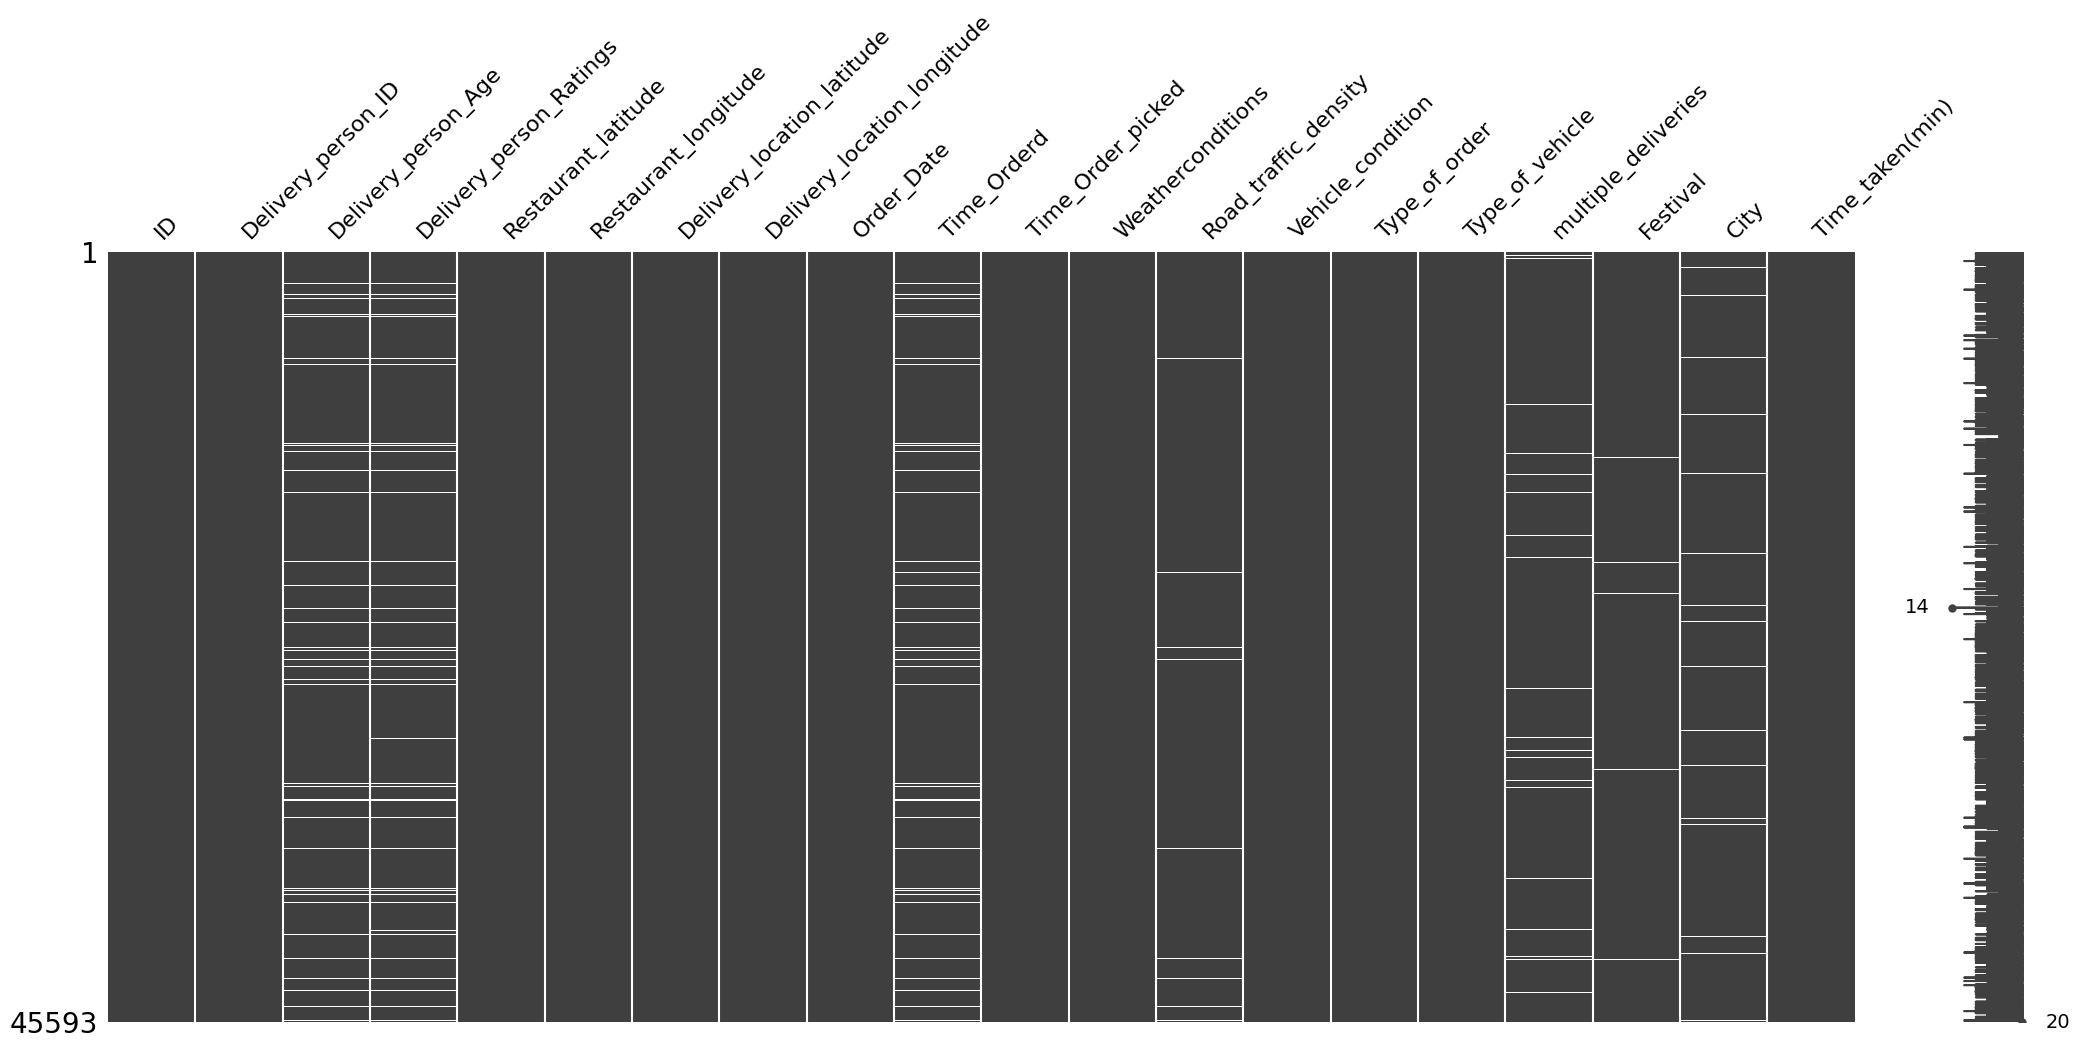

In [23]:
msno.matrix(missing_df)

In [24]:
# delivery_person_age, delivery_person_rating, time_orderd have a common pattern in missing data
# weather_condition & road traffic density have a common pattern in missing data

<Axes: >

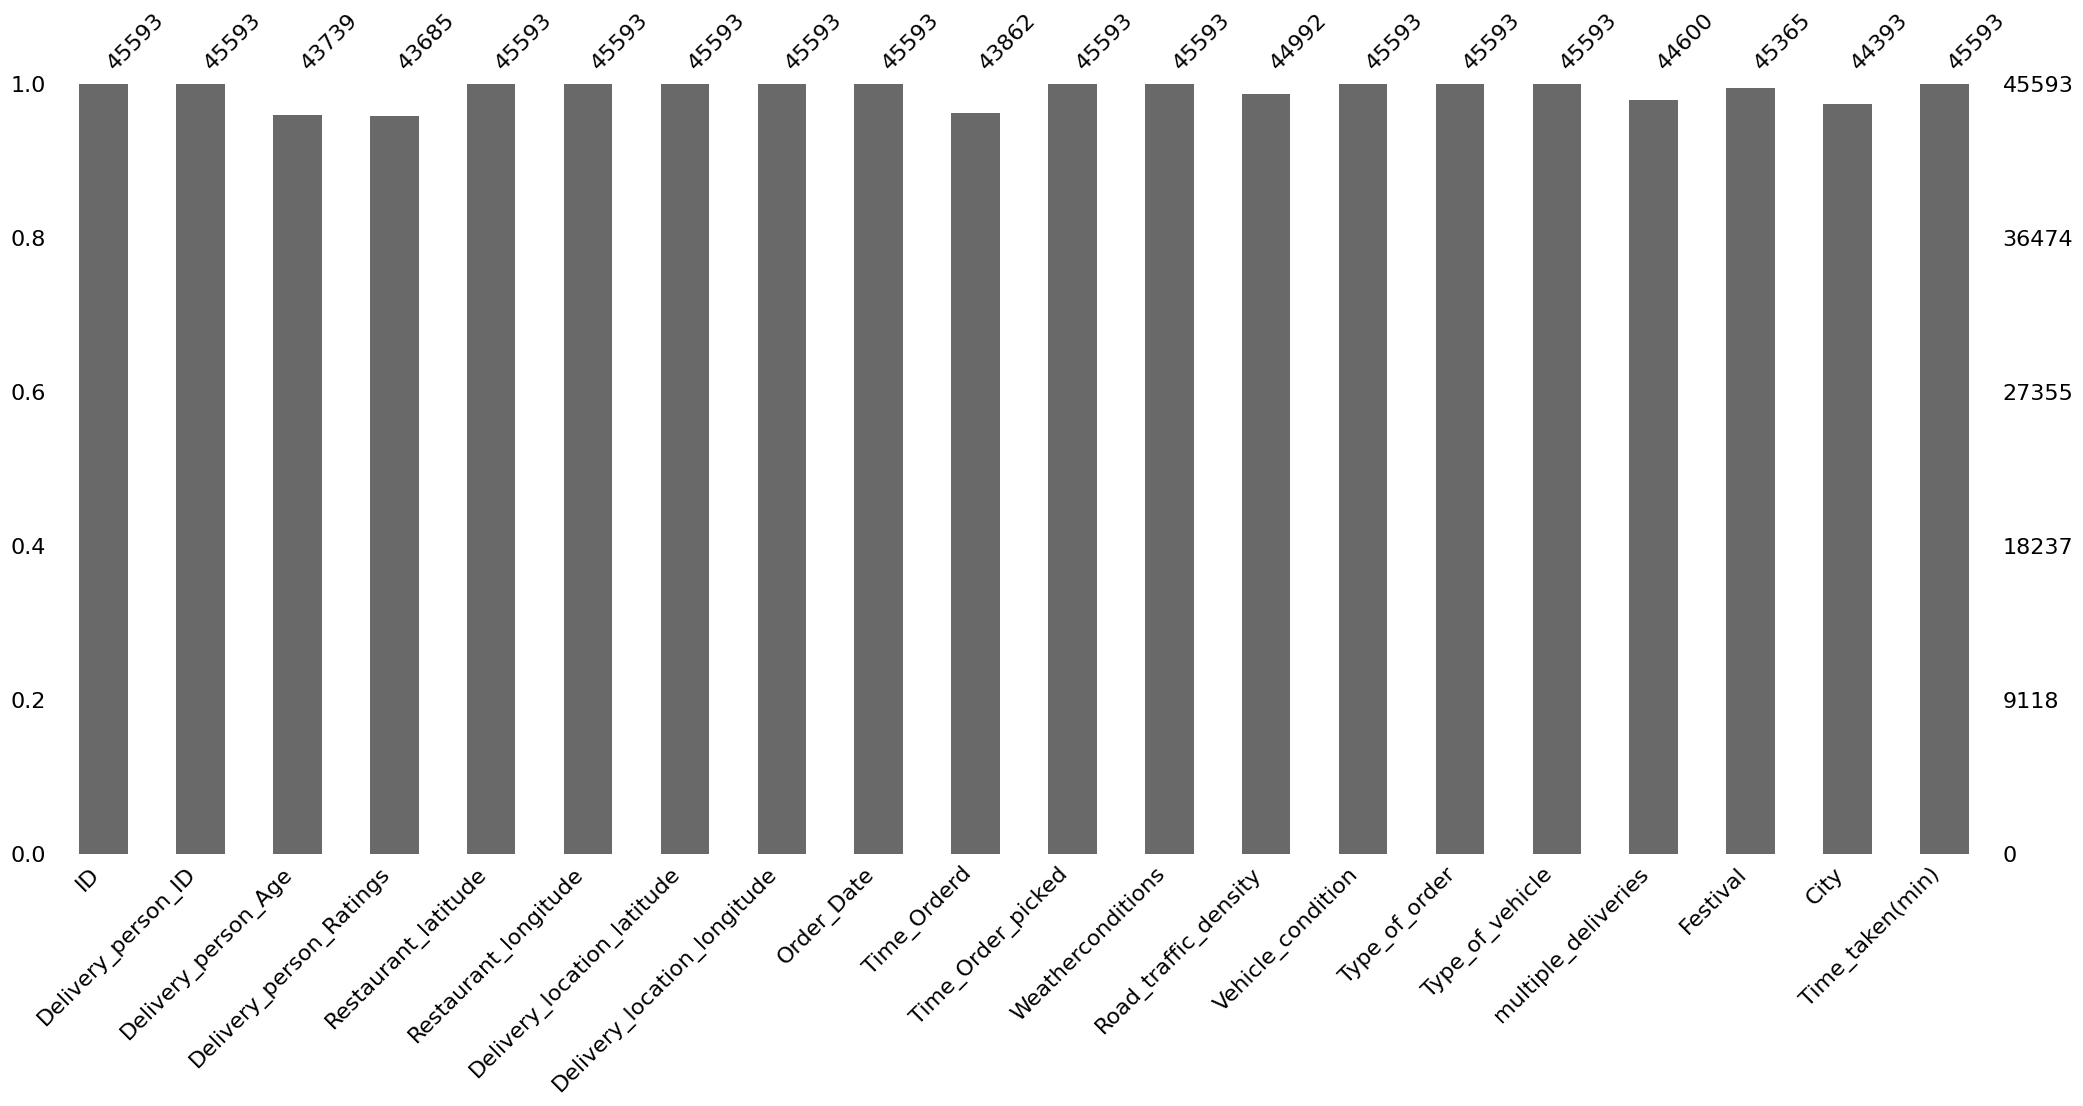

In [25]:
#count of missing values
msno.bar(missing_df)

<Axes: >

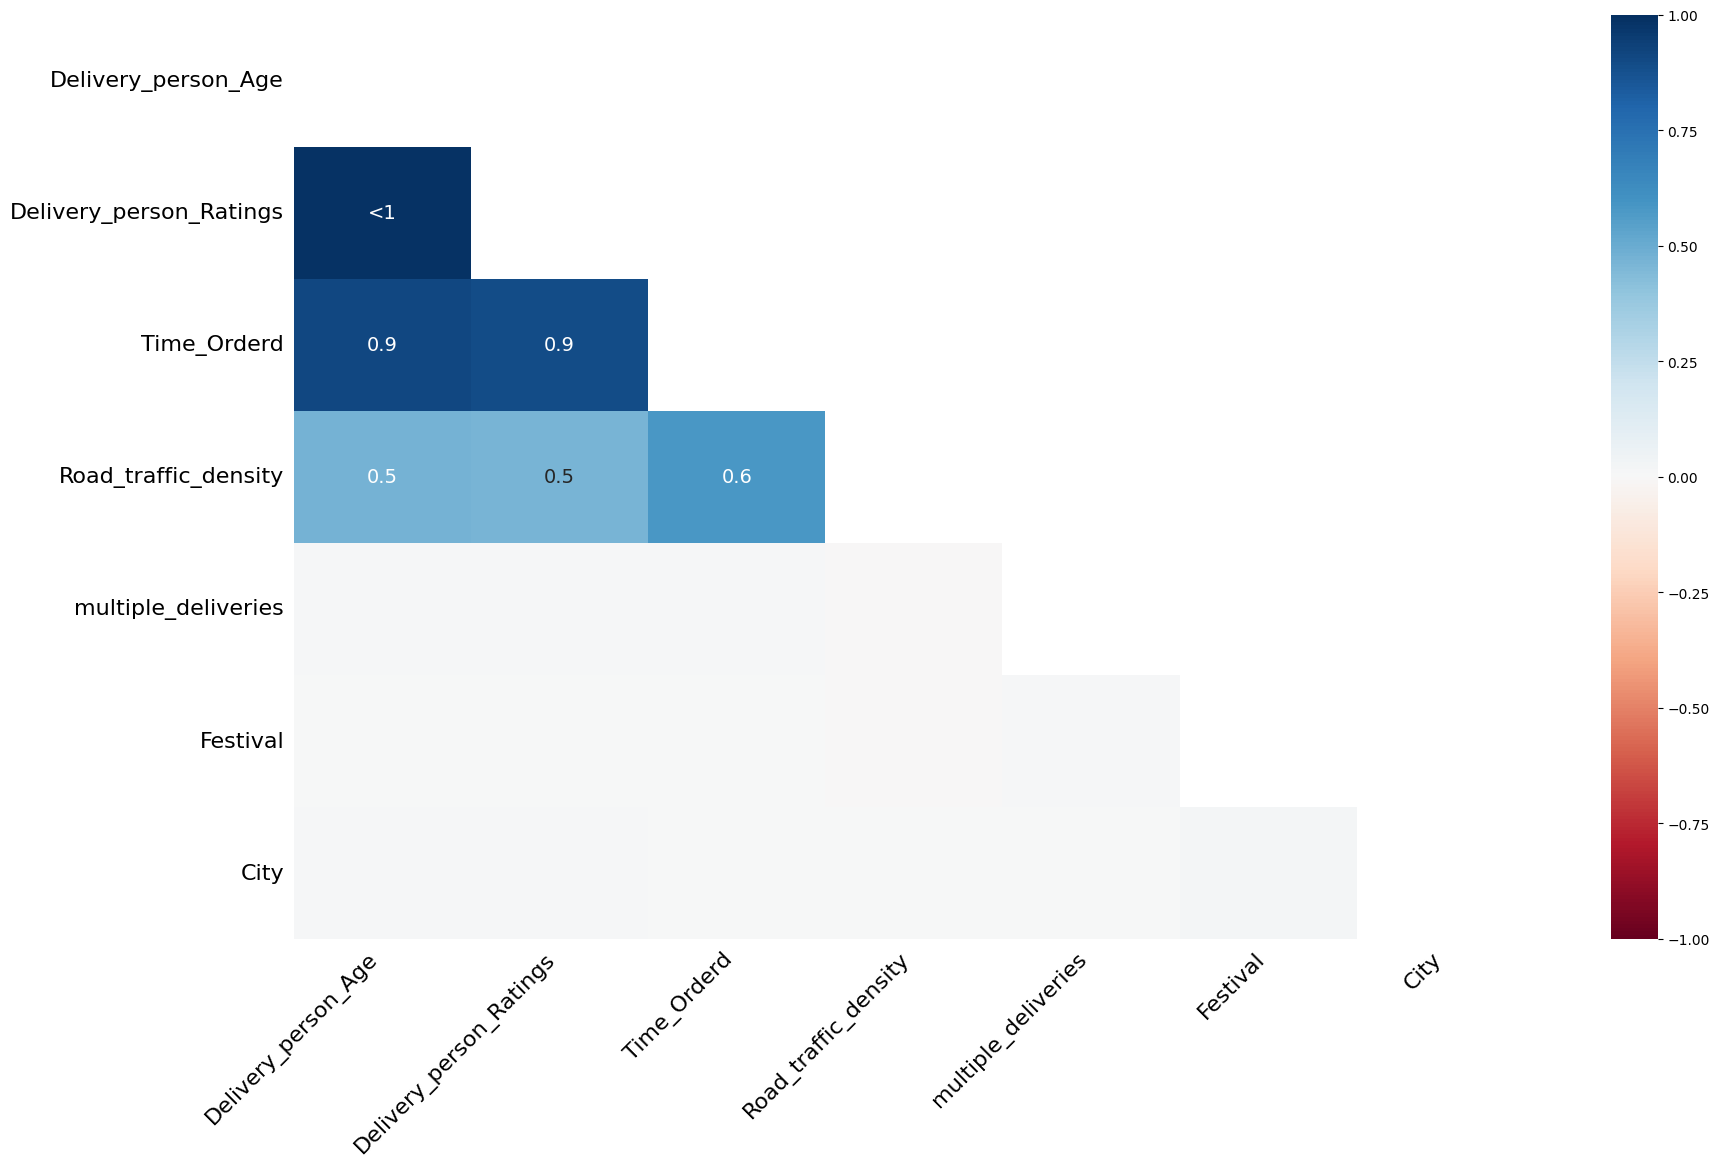

In [26]:
#missing value correlation
msno.heatmap(missing_df)

In [27]:
# delivery person rating, timeoderd and road traffic density are corelated in terms of missingness with delivery person age, delivery person ratings

In [28]:
missing_df[['Weatherconditions','Road_traffic_density']].isna().sum()

Weatherconditions         0
Road_traffic_density    601
dtype: int64

In [29]:
#prove point of missingness
missing_df[['Weatherconditions','Road_traffic_density']].isna().all(axis=1).sum() / missing_df[['Weatherconditions','Road_traffic_density']].isna().sum()

Weatherconditions       NaN
Road_traffic_density    0.0
dtype: float64

<Axes: >

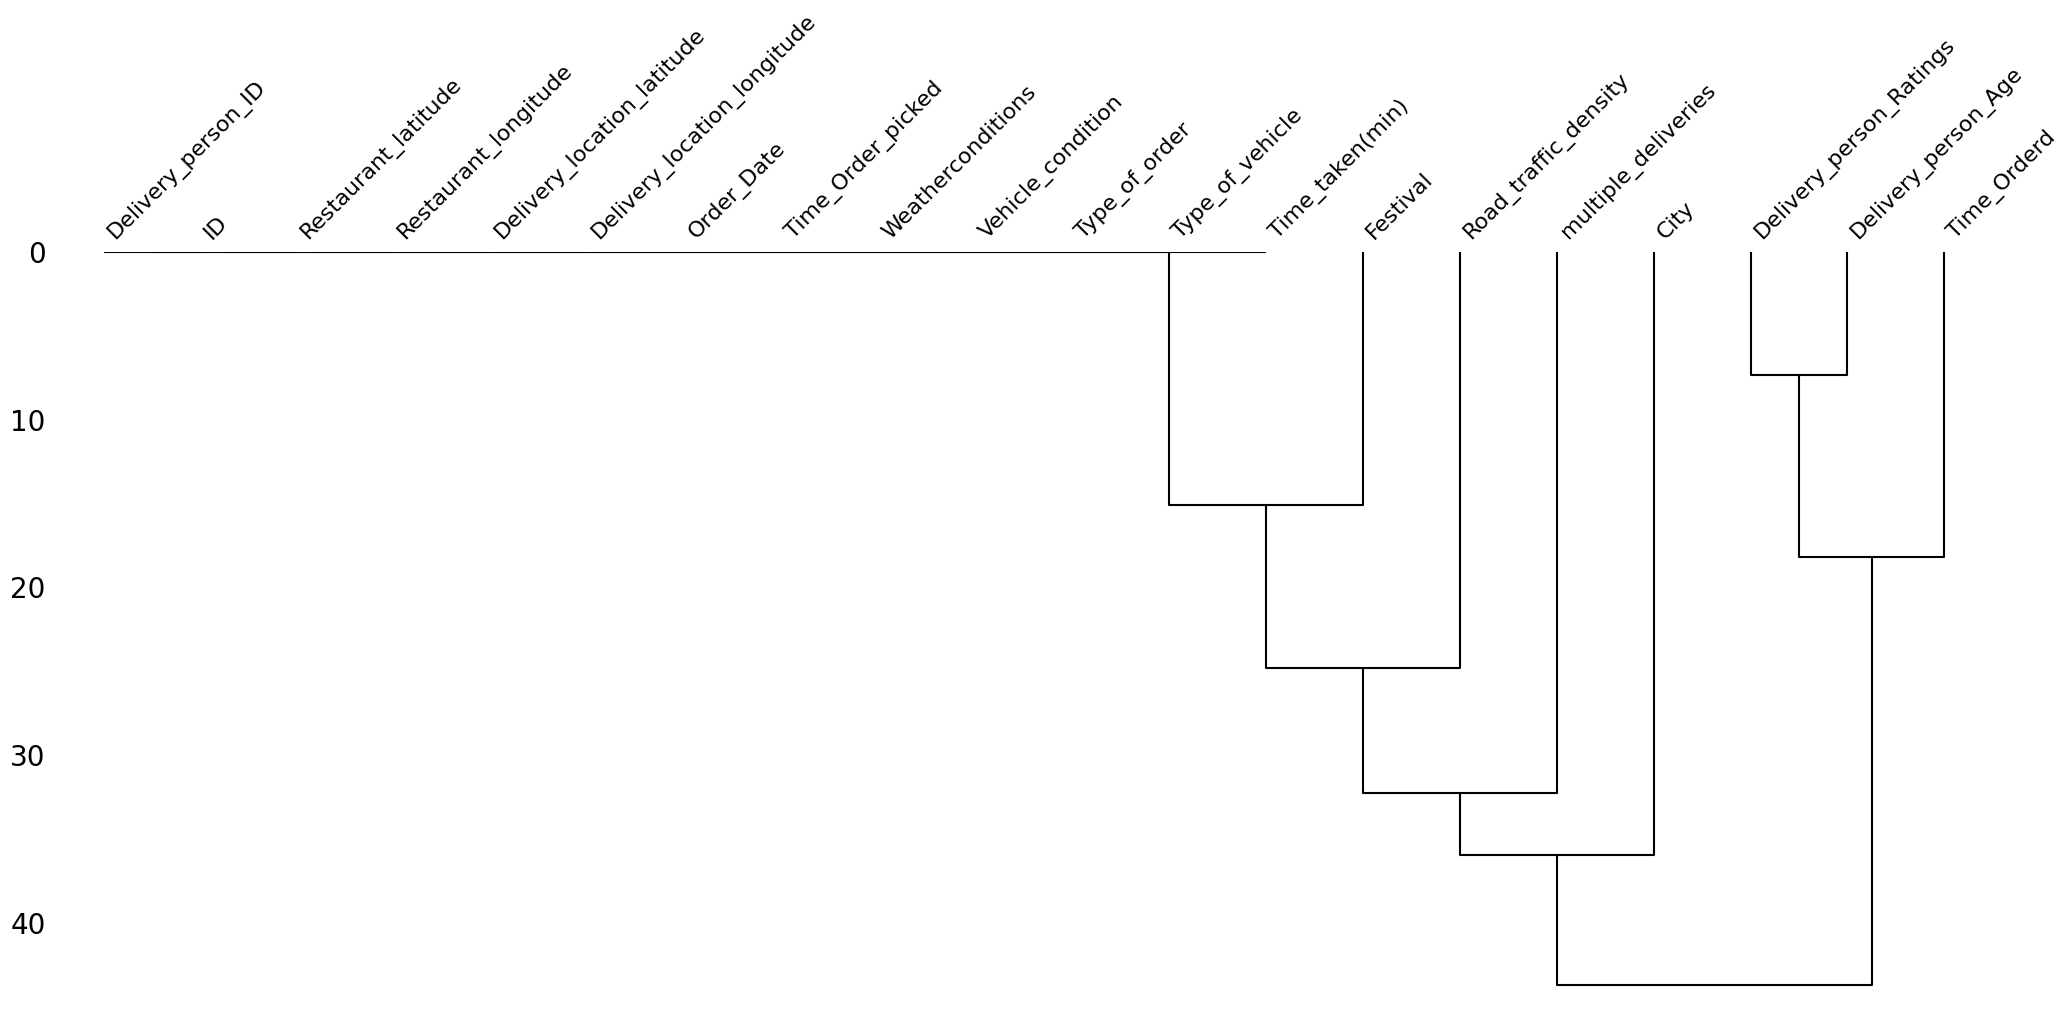

In [30]:
#dendrogram
msno.dendrogram(missing_df)

In [31]:
#pct of rows in data having missing values
(missing_df.isna().any(axis=1).sum() / missing_df.shape[0]) * 100

np.float64(9.266773408198627)

In [32]:
#about 9% of the rows in data have missing values

# Data Cleaning

In [33]:
df.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken(min)']

In [34]:
def change_column_names(data: pd.DataFrame):

    return (
        data
        .rename(str.lower, axis=1)
        .rename({
            'delivery_person_id': 'rider_id',
            'delivery_person_age': 'age',
            'delivery_person_ratings': 'ratings',
            'delivery_location_latitude': 'delivery_latitude',
            'delivery_location_longitude': 'delivery_longitude',
            'time_orderd': 'order_time',
            'time_order_picked': 'order_picked_time',
            'weatherconditions': 'weather',
            'road_traffic_density': 'traffic',
            'city': 'city_type',
            'time_taken(min)': 'time_taken'
        }, axis=1)
    )

In [35]:
#change column names
df = change_column_names(df)

In [36]:
df.columns

Index(['id', 'rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken'],
      dtype='object')

In [37]:
#check for duplicate rows
df.drop(columns=['id','rider_id']).duplicated().sum()

np.int64(0)

## column wise cleaning

### id

In [38]:
# unique ids in id col
df['id'].nunique()

45593

In [39]:
#no unique ids in this col, we can drop this col

### rider id

In [40]:
df['rider_id'].nunique()

1320

In [41]:
df['rider_id'].value_counts()

rider_id
PUNERES01DEL01       67
JAPRES11DEL02        67
VADRES08DEL02        66
RANCHIRES02DEL01     66
HYDRES04DEL02        66
                     ..
BHPRES15DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64

In [42]:
#extarct city names from rider id
df['rider_id'].str.split("RES").str.get(0).rename('city_name')

0          INDO
1          BANG
2          BANG
3         COIMB
4          CHEN
          ...  
45588       JAP
45589       AGR
45590      CHEN
45591     COIMB
45592    RANCHI
Name: city_name, Length: 45593, dtype: object

### age

In [43]:
df['age'].dtype

dtype('O')

In [44]:
#min, mean & max values
df['age'].astype(float).describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

In [45]:
# min rider age is min which is against labour law
# investigate further what tyoe of vehicle is he using

<Axes: ylabel='age'>

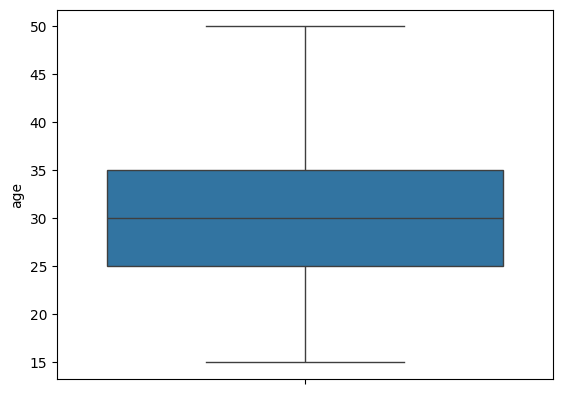

In [46]:
#box plot of age col
sns.boxplot(df['age'].astype(float))

In [47]:
#rows of data where age is < 18
minors_df = df.loc[df['age'].astype('float') < 18]
minors_df

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
2387,0x564,JAPRES15DEL03,15,1,-26.891191,75.802083,26.981191,75.892083,12-03-2022,NaN,17:20:00,conditions NaN,NaN,3,Meal,motorcycle,0,No,Urban,(min) 15
2905,0xcd0,INDORES010DEL03,15,1,22.750040,75.902847,22.810040,75.962847,03-04-2022,NaN,20:30:00,conditions NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 29
2951,0x91a,SURRES17DEL03,15,1,21.149569,72.772697,21.209569,72.832697,21-03-2022,NaN,22:10:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 20
5902,0x474,CHENRES15DEL03,15,1,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50:00,conditions NaN,NaN,3,Drinks,bicycle,1,No,Metropolitian,(min) 25
9156,0x73f,BANGRES05DEL01,15,1,12.970324,77.645748,13.080324,77.755748,25-03-2022,NaN,23:25:00,conditions NaN,NaN,3,Buffet,motorcycle,2,No,Metropolitian,(min) 34
10900,0x1b49,MUMRES14DEL02,15,1,19.181300,72.836191,19.231300,72.886191,30-03-2022,NaN,20:55:00,conditions NaN,NaN,3,Buffet,motorcycle,1,No,Metropolitian,(min) 39
11125,0x40b,SURRES12DEL01,15,1,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30:00,conditions NaN,NaN,3,Meal,scooter,1,No,Urban,(min) 27
12093,0x523,INDORES03DEL02,15,1,22.751857,75.866699,22.801857,75.916699,24-03-2022,NaN,21:15:00,conditions NaN,NaN,3,Buffet,bicycle,0,No,Metropolitian,(min) 28
15124,0x18b0,RANCHIRES02DEL01,15,1,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55:00,conditions NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 21
15927,0x550,CHENRES08DEL02,15,1,13.022394,80.242439,13.072394,80.292439,11-03-2022,NaN,18:10:00,conditions NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 17


In [48]:
#star ratings of all riders is 1
#no variability in age, exactly 15 for all
#restaurant_lat long contains negative values also
#order time, weather traffic values are all NaN
#vehicle_condition is also 3 which is very bad

#we should remove these rows, bcoz of a lot of missing values
#and messing with distribution of data

In [49]:
minor_index = minors_df.index.tolist()
len(minor_index)

38

### ratings

In [50]:
df['ratings'].astype(float).describe()

count    43685.000000
mean         4.633780
std          0.334716
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

In [51]:
#max rating is 6 which seems to be an error
#generally ratings goes from 1 to 5
#75 percentile values are 4.9

<Axes: ylabel='ratings'>

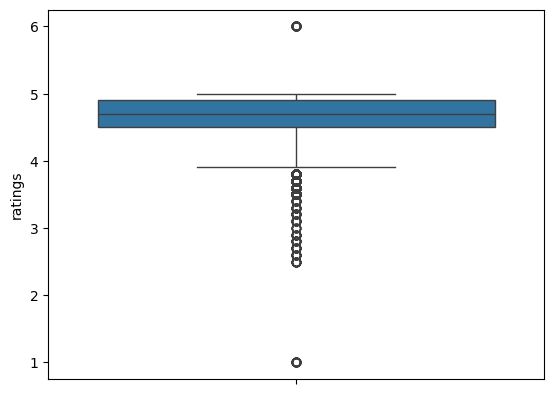

In [52]:
sns.boxplot(df['ratings'].astype(float))

In [53]:
six_stars_data = df.loc[df['ratings'] == "6"]

In [54]:
print(len(six_stars_data))
six_stars_data

53


,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
3586,0x46d,BANGRES05DEL01,50,6,-12.970324,-77.645748,13.010324,77.685748,13-03-2022,NaN,12:30:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 25
4714,0x493,HYDRES17DEL01,50,6,-17.451976,-78.385883,17.561976,78.495883,04-04-2022,NaN,23:20:00,conditions NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 27
5169,0x4f2,JAPRES08DEL01,50,6,-26.910262,-75.783013,27.020262,75.893013,18-03-2022,NaN,18:50:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20
5362,0x430,BANGRES19DEL01,50,6,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,20:55:00,conditions NaN,NaN,3,Meal,electric_scooter,1,No,Metropolitian,(min) 18
5651,0xbef1,AGRRES13DEL02,50,6,-27.159795,-78.042990,27.209795,78.092990,13-02-2022,NaN,18:05:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20
6394,0x427,JAPRES06DEL02,50,6,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,22:10:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 20
7031,0x3eb,MYSRES15DEL02,50,6,-12.352058,-76.606650,12.372058,76.626650,15-03-2022,NaN,10:00:00,conditions NaN,NaN,3,Buffet,scooter,1,No,Metropolitian,(min) 14
7681,0xd42,VADRES09DEL01,50,6,0.000000,0.000000,0.010000,0.010000,21-03-2022,NaN,08:35:00,conditions NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 22
9499,0x3f0,BANGRES010DEL01,50,6,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,18:25:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Urban,(min) 17
9535,0x3ef,RANCHIRES13DEL01,50,6,-23.374989,-85.335486,23.444989,85.405486,20-03-2022,NaN,17:55:00,conditions NaN,NaN,3,Snack,bicycle,1,No,Metropolitian,(min) 32


In [55]:
#it looks same as minors data
#we should remove these rows also

In [56]:
six_star_index = six_stars_data.index.tolist()

### locations

In [57]:
loc_cols = df.columns[4:8].tolist()
loc_cols

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [58]:
location_subset = df.loc[:,loc_cols]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
45588,26.902328,75.794257,26.912328,75.804257
45589,0.000000,0.000000,0.070000,0.070000
45590,13.022394,80.242439,13.052394,80.272439
45591,11.001753,76.986241,11.041753,77.026241


In [59]:
#India is located north of the equator, between latitudes 6°44' N and 35°30' N, and longitudes 68°7' E and 97°25' E.

In [60]:
location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [61]:
# min values are negative in restraunt lat long and 0s in delivery lat long
# both are not possible since correct lat range should be b/w 6 to 35 and correct long range should be 68 to 97

In [62]:
#set lower bound limits for lat long
lower_bound_lat = 6.44
lower_bound_long = 68.7

In [63]:
#rows where lat long values are below bound
location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].sample(20)

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
8569,0.000000,0.000000,0.070000,0.070000
34171,0.000000,0.000000,0.040000,0.040000
15122,0.000000,0.000000,0.090000,0.090000
17170,0.000000,0.000000,0.030000,0.030000
35548,-23.371292,85.327872,23.401292,85.357872
31854,0.000000,0.000000,0.070000,0.070000
40992,0.000000,0.000000,0.080000,0.080000
33805,0.000000,0.000000,0.130000,0.130000
31062,0.000000,0.000000,0.020000,0.020000
33760,0.000000,0.000000,0.040000,0.040000


In [64]:
#rows where lat long values are below bound
location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].shape

(4071, 4)

In [65]:
#rows where lat long values are below bound
location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,4071.000000,4071.000000,4071.000000,4071.000000
mean,-2.149416,2.068601,2.212538,8.299885
std,6.537913,25.270676,6.538283,23.980011
min,-30.905562,-88.366217,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.523452


<Axes: >

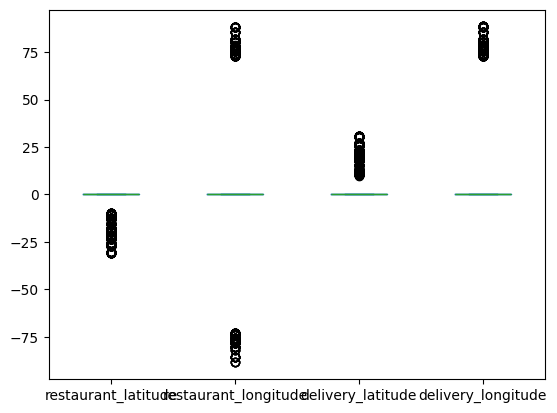

In [66]:
#box plot for all anomolies
location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].plot(kind='box')

In [67]:
#negative values are correct, we just need to take absolute values
#we cant fill 0s with mean or median bcoz it will invalidate data distribution
#we can fill those with nan values and impute them using advanced imputation techniques
#or since we need lat long to calculate distance only so we can calculate distance for the rows where lat longs are correct and then fill missing details values with avg distance

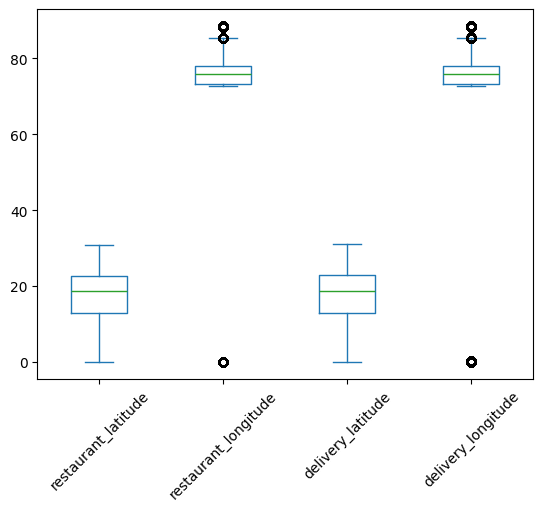

In [68]:
import matplotlib.pyplot as plt

location_subset.abs().plot(kind='box')
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

In [69]:
#negative value issue is solved -- 0s are still there

In [70]:
#rows remaining after taking absolute values
location_subset.abs().loc[lambda df_:
    (df_['restaurant_latitude'] < lower_bound_lat) |
    (df_['restaurant_longitude'] < lower_bound_long) |
    (df_['delivery_latitude'] < lower_bound_lat) |
    (df_['delivery_longitude'] < lower_bound_long)
].shape

(3640, 4)

In [71]:
#out of 4071 -- 3640 remaining

In [72]:
#lat long values < 1

location_subset.abs().loc[lambda df_:
    (df_['restaurant_latitude'] < 1) |
    (df_['restaurant_longitude'] < 1) |
    (df_['delivery_latitude'] < 1) |
    (df_['delivery_longitude'] < 1)
]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
33,0.0,0.0,0.11,0.11
52,0.0,0.0,0.03,0.03
57,0.0,0.0,0.08,0.08
59,0.0,0.0,0.06,0.06
67,0.0,0.0,0.02,0.02
...,...,...,...,...
45569,0.0,0.0,0.07,0.07
45576,0.0,0.0,0.13,0.13
45577,0.0,0.0,0.09,0.09
45579,0.0,0.0,0.05,0.05


In [73]:
# all messy lat long values are less then 1

In [74]:
def clean_lat_long(data:pd.DataFrame, threshold=1):
    location_columns = location_subset.columns.tolist()

    return(
        data.assign(**{
            col:(
                np.where(data[col] < threshold, np.nan, data[col].values)
            )
            for col in location_columns
        })
    )

In [75]:
clean_lat_long(df).isna().sum()

id                         0
rider_id                   0
age                        0
ratings                    0
restaurant_latitude     4071
restaurant_longitude    3802
delivery_latitude       3640
delivery_longitude      3640
order_date                 0
order_time                 0
order_picked_time          0
weather                    0
traffic                    0
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries        0
festival                   0
city_type                  0
time_taken                 0
dtype: int64

### order date

In [76]:
df['order_date'].isna().sum()

np.int64(0)

In [77]:
df['order_date'].unique()

array(['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022',
       '11-03-2022', '04-03-2022', '14-03-2022', '20-03-2022',
       '12-02-2022', '13-02-2022', '14-02-2022', '02-04-2022',
       '01-03-2022', '16-03-2022', '15-02-2022', '10-03-2022',
       '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
       '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022',
       '28-03-2022', '18-03-2022', '06-04-2022', '04-04-2022',
       '24-03-2022', '09-03-2022', '02-03-2022', '13-03-2022',
       '29-03-2022', '31-03-2022', '17-03-2022', '07-03-2022',
       '15-03-2022', '16-02-2022', '03-03-2022', '18-02-2022',
       '23-03-2022', '17-02-2022', '06-03-2022', '21-03-2022'],
      dtype=object)

In [78]:
#date range
order_date = pd.to_datetime(df['order_date'], dayfirst=True)
order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [79]:
#min max dates
order_date.agg(['min','max']).set_axis(['start','end'], axis=0)

start   2022-02-11
end     2022-04-06
Name: order_date, dtype: datetime64[ns]

In [80]:
#extract day, day name, month and year
def extract_datetime_features(ser):
    date_col = pd.to_datetime(ser, dayfirst=True)

    return(
        pd.DataFrame({
        'day':date_col.dt.day,
        'month':date_col.dt.month,
        'year':date_col.dt.year,
        'day_of_week':date_col.dt.day_name(),
        'is_weekend':date_col.dt.day_name().isin(['Saturday','Sunday']).astype(int)
    }))

In [81]:
extract_datetime_features(df['order_date'])

,day,month,year,day_of_week,is_weekend
0,19,3,2022,Saturday,1
1,25,3,2022,Friday,0
2,19,3,2022,Saturday,1
3,5,4,2022,Tuesday,0
4,26,3,2022,Saturday,1
...,...,...,...,...,...
45588,24,3,2022,Thursday,0
45589,16,2,2022,Wednesday,0
45590,11,3,2022,Friday,0
45591,7,3,2022,Monday,0


In [82]:
#drop year since its not changing

### order time and order picked time

In [83]:
# extract hour info from data
order_time_hr = (
    pd.to_datetime(
        df['order_time'].replace(r'^\s*NaN\s*$', np.nan, regex=True),
        format='mixed',
        errors='coerce'
    )
    .dt.hour
)

order_time_hr

0        11.0
1        19.0
2         8.0
3        18.0
4        13.0
         ... 
45588    11.0
45589    19.0
45590    23.0
45591    13.0
45592    17.0
Name: order_time, Length: 45593, dtype: float64

In [98]:
# def time_of_the_day(ser):
#     hour = pd.to_datetime(ser, errors='coerce', format='mixed').dt.hour
    
#     return np.select(
#         condlist=[
#             hour.between(6, 12, inclusive='left'),
#             hour.between(12, 17, inclusive='left'),
#             hour.between(17, 20, inclusive='left'),
#             hour.between(20, 24, inclusive='left')
#         ],
#         choicelist=['morning', 'afternoon', 'evening', 'night'],
#         default='after_midnight'
#     )

def time_of_the_day(ser):
    hour = ser.str.split(':').str[0].astype(float)
    return np.select(
        condlist=[
            hour.between(6, 12, inclusive='left'),
            hour.between(12, 17, inclusive='left'),
            hour.between(17, 20, inclusive='left'),
            hour.between(20, 24, inclusive='left')
        ],
        choicelist=['morning', 'afternoon', 'evening', 'night'],
        default='after_midnight'
    )

In [91]:
time_subset = df.loc[:,['order_time','order_picked_time']]
time_subset

,order_time,order_picked_time
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00
...,...,...
45588,11:35:00,11:45:00
45589,19:55:00,20:10:00
45590,23:50:00,00:05:00
45591,13:35:00,13:40:00


In [92]:
time_subset.dtypes

order_time           object
order_picked_time    object
dtype: object

In [93]:
time_subset.columns.tolist()

['order_time', 'order_picked_time']

In [99]:
# time_subset.assign(
#     **{
#         col: pd.to_datetime(time_subset[col].replace(r'^\s*NaN\s*$', np.nan, regex=True), format='mixed', errors='coerce')
#         for col in time_subset.columns.tolist()
#     }
# ).assign(
#     pickup_time=lambda x: (x['order_picked_time'] - x['order_time']).dt.seconds / 60,
#     order_time_hour=lambda x: x['order_time'].dt.hour,
#     order_time_of_day=lambda x: x['order_time_hour'].pipe(time_of_the_day)
# ).drop(columns=['order_time', 'order_picked_time'])


clean_times = time_subset[
    ~time_subset['order_time'].str.contains('NaN', na=False) & 
    ~time_subset['order_picked_time'].str.contains('NaN', na=False)
].copy()


clean_times.assign(
    order_time_dt=pd.to_datetime(clean_times['order_time'], format='%H:%M:%S'),
    order_picked_time_dt=pd.to_datetime(clean_times['order_picked_time'], format='%H:%M:%S')
).assign(
    pickup_time=lambda x: (x['order_picked_time_dt'] - x['order_time_dt']).dt.total_seconds() / 60,
    order_time_hour=lambda x: x['order_time_dt'].dt.hour,
    order_time_of_day=lambda x: time_of_the_day(x['order_time'])
).drop(columns=['order_time', 'order_picked_time', 'order_time_dt', 'order_picked_time_dt'])

,pickup_time,order_time_hour,order_time_of_day
0,15.0,11,morning
1,5.0,19,evening
2,15.0,8,morning
3,10.0,18,evening
4,15.0,13,afternoon
...,...,...,...
45588,10.0,11,morning
45589,15.0,19,evening
45590,-1425.0,23,night
45591,5.0,13,afternoon


### weather

In [100]:
df['weather'].value_counts()

weather
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [106]:
#unique values
df['weather'].unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy',
       'conditions NaN'], dtype=object)

In [103]:
df['weather'].str.replace('conditions ','').unique()

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', 'NaN'],
      dtype=object)

### traffic

In [104]:
df['traffic'].value_counts()

traffic
Low        15477
Jam        14143
Medium     10947
High        4425
NaN          601
Name: count, dtype: int64

In [105]:
df['traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', 'NaN '], dtype=object)

In [114]:
df['traffic'].astype(str).str.replace('NaN', '', regex=False).str.strip().str.lower().replace('', np.nan).unique()

array(['high', 'jam', 'low', 'medium', nan], dtype=object)

### vehicale condition

In [115]:
np.sort(df['vehicle_condition'].unique())

array([0, 1, 2, 3])

### type of order

In [116]:
df['type_of_order'].value_counts()

type_of_order
Snack      11533
Meal       11458
Drinks     11322
Buffet     11280
Name: count, dtype: int64

In [117]:
df['type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [118]:
df['type_of_order'].str.rstrip().str.lower().unique()

array(['snack', 'drinks', 'buffet', 'meal'], dtype=object)

### type of vehicles

In [119]:
df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle           26435
scooter              15276
electric_scooter      3814
bicycle                 68
Name: count, dtype: int64

In [120]:
df['type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

In [122]:
df['type_of_vehicle'].str.rstrip().str.lower().unique()

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

### multiple deliveries

In [123]:
df['multiple_deliveries'].dtype

dtype('O')

In [124]:
df['multiple_deliveries'].unique()

array(['0', '1', '3', 'NaN ', '2'], dtype=object)

In [125]:
#convert this col into integer
df['multiple_deliveries'].replace('NaN',np.nan).astype('float').unique()

array([ 0.,  1.,  3., nan,  2.])

### festival

In [126]:
df['festival'].unique()

array(['No ', 'Yes ', 'NaN '], dtype=object)

In [127]:
df['festival'].replace('NaN',np.nan).str.rstrip().str.lower().unique()

array(['no', 'yes', 'nan'], dtype=object)

### city type

In [128]:
df['city_type'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN '], dtype=object)

In [129]:
df['city_type'].replace('NaN',np.nan).str.rstrip().str.lower().unique()

array(['urban', 'metropolitian', 'semi-urban', 'nan'], dtype=object)

### time taken

In [130]:
df['time_taken'].dtype

dtype('O')

In [131]:
df['time_taken'].str.replace("(min)","").astype(int)

0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: time_taken, Length: 45593, dtype: int64

## Perform cleaning and feature all at once

In [ ]:
def data_cleaning(data: pd.DataFrame):
    # First, convert problematic columns to string to avoid .str accessor errors
    df_cleaned = data.copy()
    
    # Convert string columns that will use .str accessor
    str_columns = ['rider_id', 'weather', 'traffic', 'type_of_order', 
                   'type_of_vehicle', 'festival', 'city_type', 'time_taken']
    
    for col in str_columns:
        if col in df_cleaned.columns:
            df_cleaned[col] = df_cleaned[col].astype(str)
    
    return(
        df_cleaned
            .drop(columns='id')
            .drop(index=minor_index)
            .drop(index=six_star_index)
            .replace('NaN', np.nan)
            .assign(
                #city name out of rider id
                city_name = lambda x: x['rider_id'].str.split('RES').str.get(0),
                
                #convert age to float
                age = lambda x: pd.to_numeric(x['age'], errors='coerce'),
                
                #convert rating to float
                ratings = lambda x: pd.to_numeric(x['ratings'], errors='coerce'),
                
                #absolute values for location based columns
                restaurant_latitude = lambda x: x['restaurant_latitude'].abs(),
                restaurant_longitude = lambda x: x['restaurant_longitude'].abs(),
                delivery_latitude = lambda x: x['delivery_latitude'].abs(),
                delivery_longitude = lambda x: x['delivery_longitude'].abs(),
                
                #order date to datetime and feature extraction
                order_date = lambda x: pd.to_datetime(x['order_date'], dayfirst=True, errors='coerce'),
                
                order_day = lambda x: x['order_date'].dt.day,
                order_month = lambda x: x['order_date'].dt.month,
                order_day_of_week = lambda x: x['order_date'].dt.day_name().str.lower(),
                
                is_weekend = lambda x: (x['order_date'].dt.day_name().isin(['Saturday','Sunday']).astype(int)),
                
                #time based cols - Handle NaN values
                order_time = lambda x: pd.to_datetime(x['order_time'], format='mixed', errors='coerce'),
                order_picked_time = lambda x: pd.to_datetime(x['order_picked_time'], format='mixed', errors='coerce'),
                
                #time taken to pick order
                pickup_time_minutes = lambda x: (
                    (x['order_picked_time'] - x['order_time']).dt.total_seconds() / 60
                ),
                
                #hour in which order was placed
                order_time_hour = lambda x: x['order_time'].dt.hour,
                
                #time of the day when order was placed
                # order_time_of_day = lambda x: (x['order_time_hour'].pipe(time_of_the_day)),  # Uncomment when time_of_the_day is defined
                
                #categorical cols - Now all are strings so .str accessor will work
                weather = lambda x: x['weather'].str.replace('conditions ', '', regex=False).str.lower().replace('nan', np.nan),
                traffic = lambda x: x['traffic'].str.strip().str.lower(),
                type_of_order = lambda x: x['type_of_order'].str.strip().str.lower(),
                type_of_vehicle = lambda x: x['type_of_vehicle'].str.strip().str.lower(),
                festival = lambda x: x['festival'].str.strip().str.lower(),
                city_type = lambda x: x['city_type'].str.strip().str.lower(),
                
                #multiple deliveries
                multiple_deliveries = lambda x: pd.to_numeric(x['multiple_deliveries'], errors='coerce'),
                
                #target col modifications
                time_taken = lambda x: x['time_taken'].str.replace('(min)', '', regex=False).str.strip().astype(float)
            )
            #drop redundant cols
            .drop(columns=['order_time','order_picked_time'])
    )

In [160]:
data_cleaning(df)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,no,urban,24.0,INDO,19,3,saturday,1,15.0,11.0
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,no,metropolitian,33.0,BANG,25,3,friday,0,5.0,19.0
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,no,urban,26.0,BANG,19,3,saturday,1,15.0,8.0
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,no,metropolitian,21.0,COIMB,5,4,tuesday,0,10.0,18.0
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,no,metropolitian,30.0,CHEN,26,3,saturday,1,15.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,no,metropolitian,32.0,JAP,24,3,thursday,0,10.0,11.0
45589,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,windy,jam,...,no,metropolitian,36.0,AGR,16,2,wednesday,0,15.0,19.0
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,no,metropolitian,16.0,CHEN,11,3,friday,0,-1425.0,23.0
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,no,metropolitian,26.0,COIMB,7,3,monday,0,5.0,13.0


## Advance cleaning

In [161]:
location_subset.columns.tolist()

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [162]:
def calculate_haversine_distance(df):
    location_columns = location_subset.columns.tolist()

    lat1 = df[location_columns[0]]
    lon1 = df[location_columns[1]]
    lat2 = df[location_columns[2]]
    lon2 = df[location_columns[3]]

    lon1,lat1,lon2,lat2 = map(np.radians,[lon1,lat1,lon2,lat2])

    dlon = lon2-lon1
    dlat = lat2-lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2

    c = 2 * np.arcsin(np.sqrt(a))
    distance = 6371 * c

    return(
        df.assign(distance = distance)          #this will add a new col distance in df
    )

In [163]:
#add more data cleaning steps
#pipe will act as a pipeline to chain multiple functions
cleaned_data = df.pipe(data_cleaning).pipe(clean_lat_long).pipe(calculate_haversine_distance)

In [164]:
cleaned_data

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,urban,24.0,INDO,19,3,saturday,1,15.0,11.0,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,metropolitian,33.0,BANG,25,3,friday,0,5.0,19.0,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,urban,26.0,BANG,19,3,saturday,1,15.0,8.0,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,metropolitian,21.0,COIMB,5,4,tuesday,0,10.0,18.0,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,metropolitian,30.0,CHEN,26,3,saturday,1,15.0,13.0,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,metropolitian,32.0,JAP,24,3,thursday,0,10.0,11.0,1.489846
45589,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,metropolitian,36.0,AGR,16,2,wednesday,0,15.0,19.0,NaN
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,metropolitian,16.0,CHEN,11,3,friday,0,-1425.0,23.0,4.657195
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,metropolitian,26.0,COIMB,7,3,monday,0,5.0,13.0,6.232393


## validate data cleaning

In [ ]:
#age
cleaned_data['age'].agg(['min','max'])

min    20.0
max    39.0
Name: age, dtype: float64

In [166]:
#ratings
cleaned_data['ratings'].agg(['min','max'])

min    2.5
max    5.0
Name: ratings, dtype: float64

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,41872.000000,41872.000000,41872.000000,41872.000000
mean,18.913696,76.921664,18.977356,76.985325
std,5.467265,3.503107,5.469056,3.503260
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065996,73.940327
50%,19.065838,76.618203,19.124049,76.662620
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


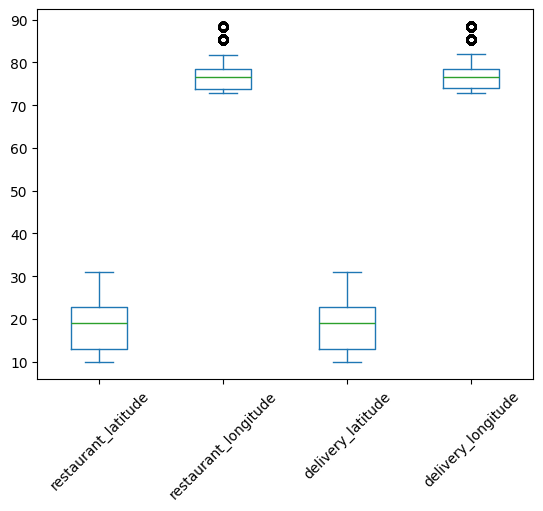

In [172]:
#location cols
cleaned_data[loc_cols].plot(kind='box')
plt.xticks(rotation=45)
display(cleaned_data[loc_cols].describe())

In [173]:
#values in categorical cols
cat_cols = cleaned_data.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"for {col} unique values are: {cleaned_data[col].unique()}", end = "\n\n")

for rider_id unique values are: ['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' ...
 'KOCRES04DEL01 ' 'BHPRES06DEL03 ' 'GOARES03DEL03 ']

for weather unique values are: ['sunny' 'stormy' 'sandstorms' 'cloudy' 'fog' 'windy' nan]

for traffic unique values are: ['high' 'jam' 'low' 'medium' 'nan']

for type_of_order unique values are: ['snack' 'drinks' 'buffet' 'meal']

for type_of_vehicle unique values are: ['motorcycle' 'scooter' 'electric_scooter' 'bicycle']

for festival unique values are: ['no' 'yes' 'nan']

for city_type unique values are: ['urban' 'metropolitian' 'semi-urban' 'nan']

for city_name unique values are: ['INDO' 'BANG' 'COIMB' 'CHEN' 'HYD' 'RANCHI' 'MYS' 'DEH' 'KOC' 'PUNE'
 'LUDH' 'KNP' 'MUM' 'KOL' 'JAP' 'SUR' 'GOA' 'AURG' 'AGR' 'VAD' 'ALH' 'BHP']

for order_day_of_week unique values are: ['saturday' 'friday' 'tuesday' 'monday' 'sunday' 'wednesday' 'thursday']



<Axes: >

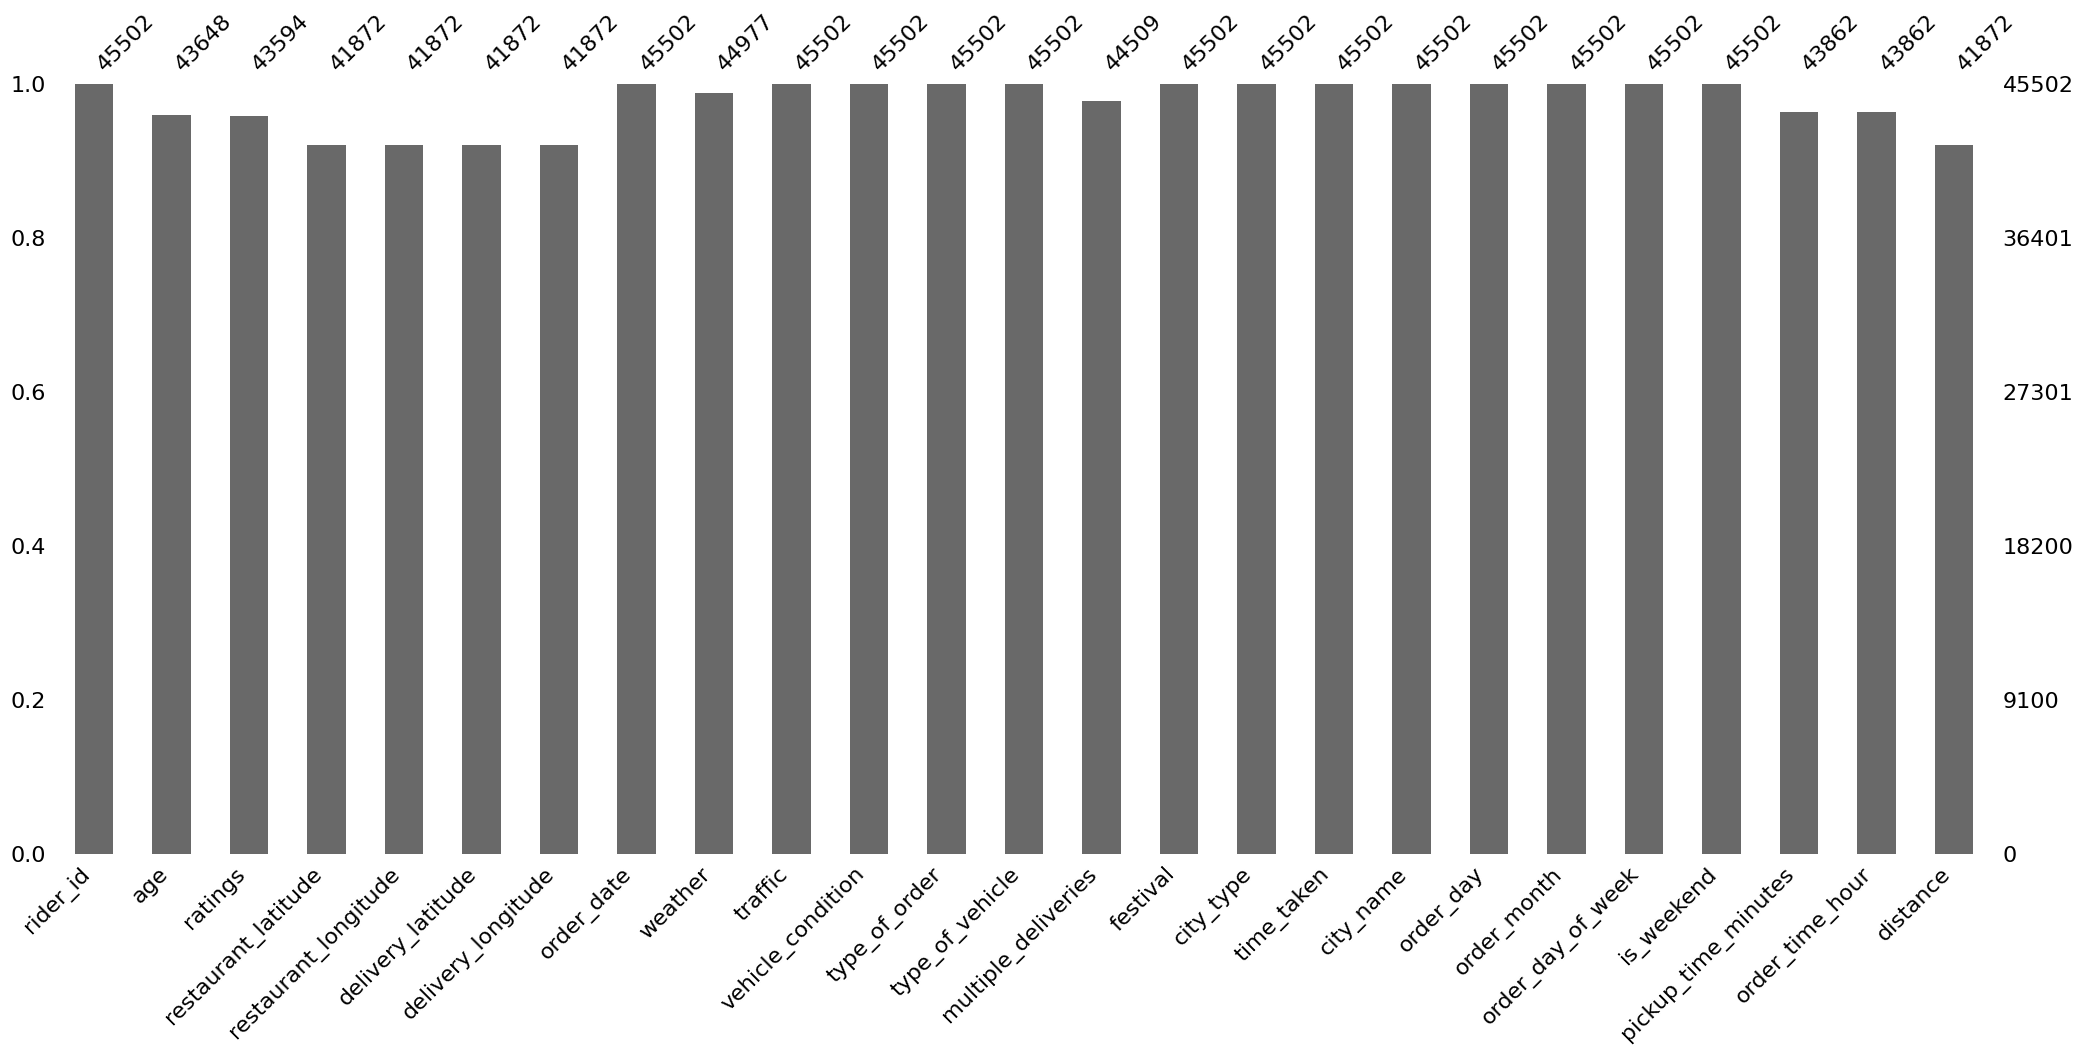

In [174]:
#bar plot for missing values
msno.bar(cleaned_data)

<Axes: >

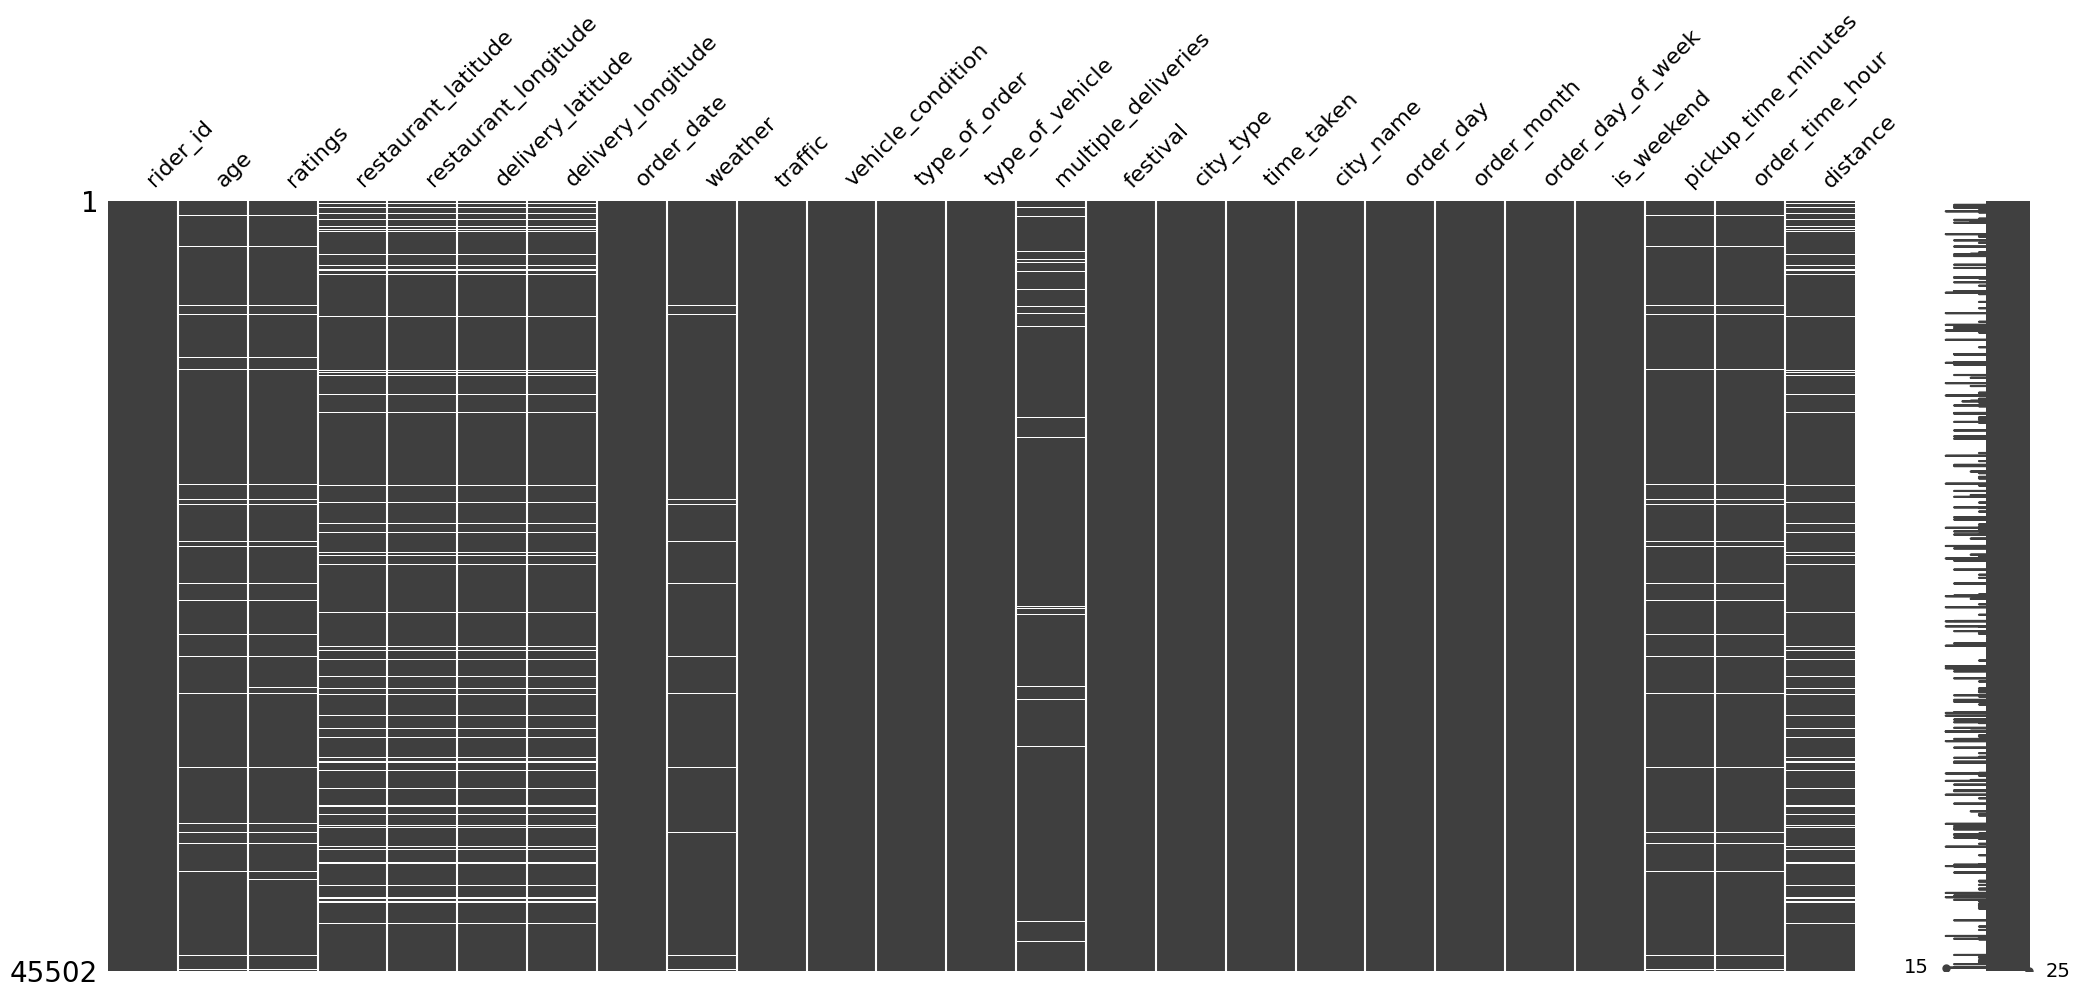

In [175]:
#matric of missing values
msno.matrix(cleaned_data)

<Axes: >

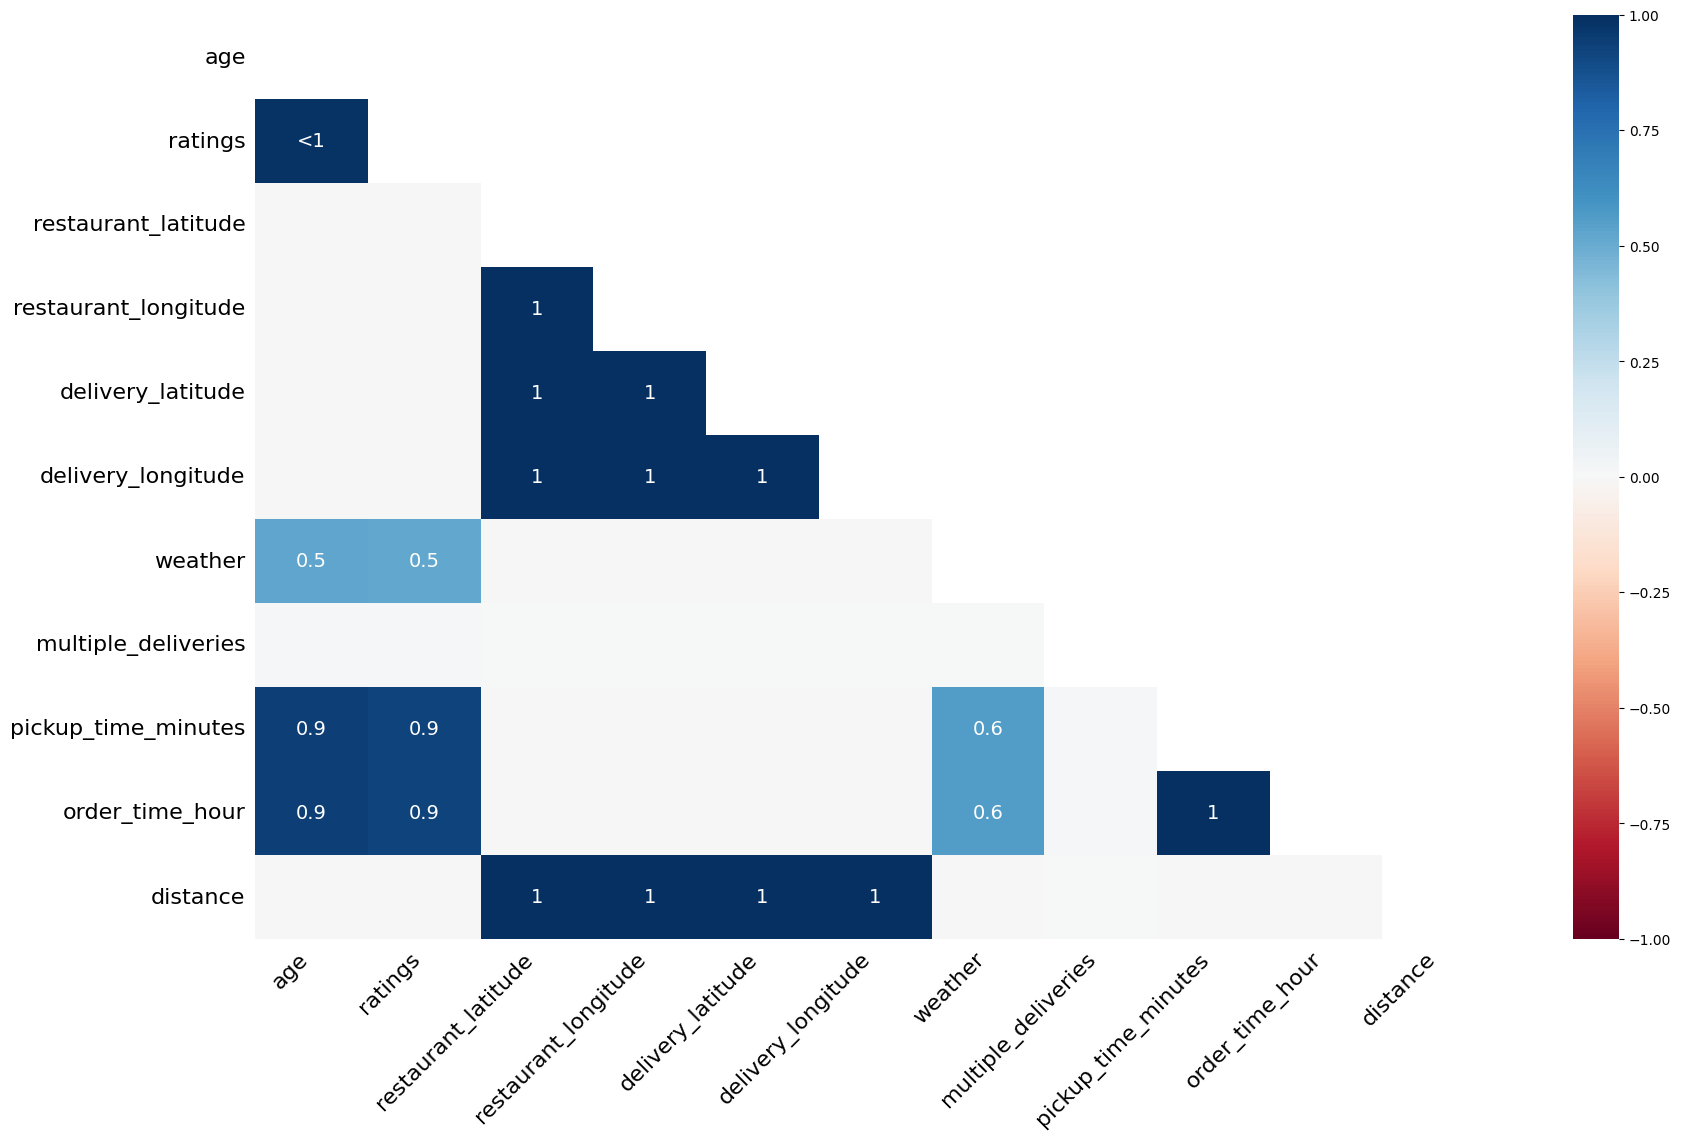

In [176]:
#corelation chart of missing values
msno.heatmap(cleaned_data)

# Save cleaned data

In [178]:
cleaned_data.to_csv('../data/cleaned_data.csv', index=False)

In [179]:
cleaned_data = pd.read_csv('../data/cleaned_data.csv')

In [180]:
cleaned_data.dtypes

rider_id                 object
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date               object
weather                  object
traffic                  object
vehicle_condition         int64
type_of_order            object
type_of_vehicle          object
multiple_deliveries     float64
festival                 object
city_type                object
time_taken              float64
city_name                object
order_day                 int64
order_month               int64
order_day_of_week        object
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
distance                float64
dtype: object